In [1]:
import pandas as pd
df = pd.read_csv('c:/data/soccer/player.csv')
df.head()

,id,player_name,birthday,preferred_foot,age,height,weight,potential,right_foot,left_foot,...,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,overall_rating,Label
0,1,Aaron Appindangoye,1992-02-29,right,27,183,187,71,1,0,...,65,69,69,6,11,10,8,8,67,0
1,2,Aaron Cresswell,1989-12-15,right,30,170,146,71,1,0,...,65,69,69,6,11,10,8,8,67,0
2,3,Aaron Doran,1991-05-13,right,28,170,163,66,1,0,...,65,66,69,6,11,10,8,8,62,0
3,4,Aaron Galindo,1982-05-08,right,37,183,198,65,1,0,...,62,63,66,5,10,9,7,7,61,0
4,5,Aaron Hughes,1979-11-08,right,40,183,154,65,1,0,...,62,63,66,5,10,9,7,7,61,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10935 entries, 0 to 10934
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  10935 non-null  int64 
 1   player_name         10935 non-null  object
 2   birthday            10935 non-null  object
 3   preferred_foot      10935 non-null  object
 4   age                 10935 non-null  int64 
 5   height              10935 non-null  int64 
 6   weight              10935 non-null  int64 
 7   potential           10935 non-null  int64 
 8   right_foot          10935 non-null  int64 
 9   left_foot           10935 non-null  int64 
 10  crossing            10935 non-null  int64 
 11  finishing           10935 non-null  int64 
 12  heading_accuracy    10935 non-null  int64 
 13  short_passing       10935 non-null  int64 
 14  volleys             10935 non-null  int64 
 15  dribbling           10935 non-null  int64 
 16  curve               10

In [6]:
train_cols = df.columns[4:43]
print(train_cols)

Index(['age', 'height', 'weight', 'potential', 'right_foot', 'left_foot',
       'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'free_kick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'marking', 'standing_tackle', 'sliding_tackle', 'gk_diving',
       'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes'],
      dtype='object')


In [7]:
X = df[train_cols]
y = df['Label']
y.value_counts()

Label
1    5705
0    5230
Name: count, dtype: int64

In [8]:
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=train_cols)
y_samp = pd.DataFrame(data=y_sample, columns=['Label'])
df_samp = pd.concat([X_samp, y_samp], axis=1)
df_samp.Label.value_counts()

Label
0    5230
1    5230
Name: count, dtype: int64

In [9]:
X = df_samp[train_cols]
y = df_samp['Label']

In [10]:
# validation_curve() : 1개의 파라미터를 튜닝하는 함수
from sklearn.model_selection import validation_curve
from sklearn.svm import SVC
# param_range 범위
param_range = [0.01, 0.1, 1, 10]
# param_name 최적화할 파라미터 이름 = C : cost, 오차에 대한 패널티  / cv 교차검증 = 2회 / scoring 성능 측정 기준 = 정확도 / n_jobs CPU용량 = -1 :전체
train_scores, test_scores = validation_curve(SVC(), X, y, param_name='C', param_range=param_range, cv=2, scoring='accuracy', n_jobs=-1)

In [11]:
print(train_scores)
print(test_scores)

[[0.81491396 0.83518164]
 [0.88489484 0.90210325]
 [0.92810707 0.9418738 ]
 [0.95391969 0.96099426]]
[[0.84225621 0.79407266]
 [0.90095602 0.8709369 ]
 [0.92887189 0.91108987]
 [0.94034417 0.92160612]]


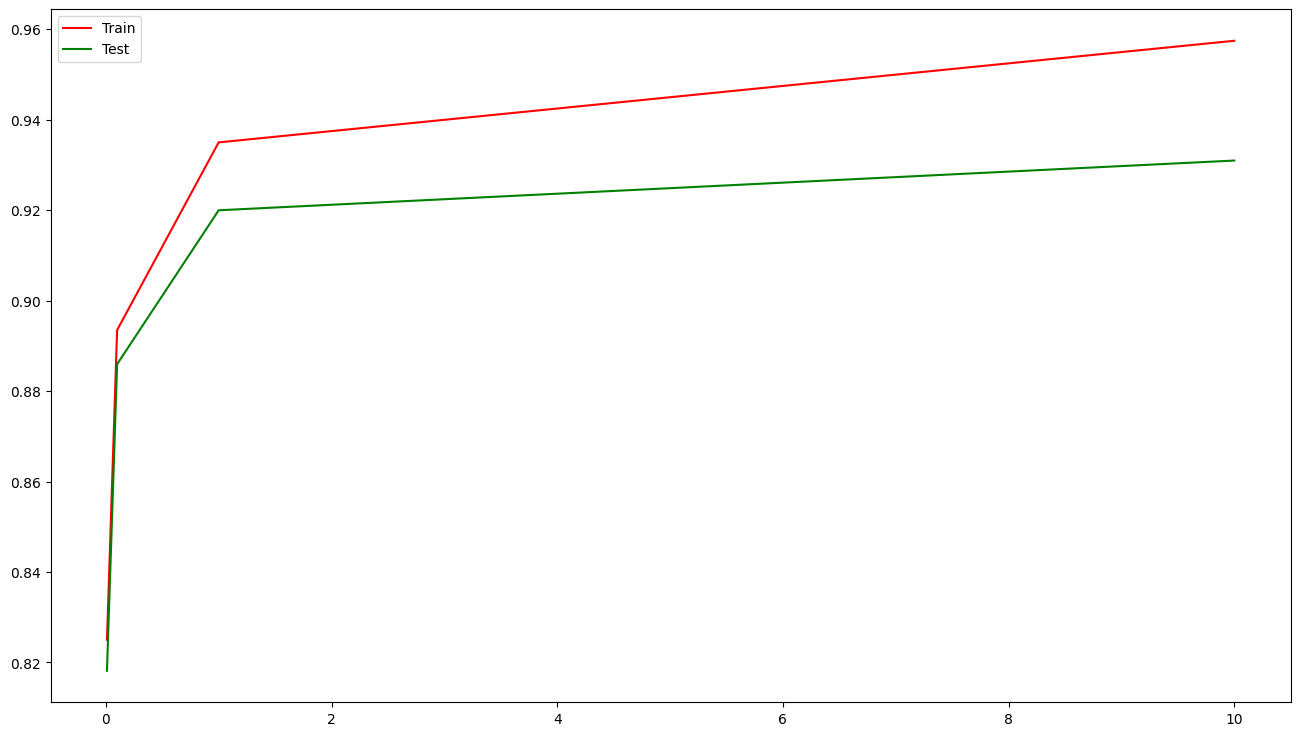

In [12]:
import matplotlib.pyplot as plt
import numpy as np
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.rcParams['figure.figsize']=(16,9)
plt.plot(param_range, train_scores_mean, label='Train', color='r')
plt.plot(param_range, test_scores_mean, label='Test', color='g')
plt.legend(loc='best')
plt.show()

In [16]:
#최적의 파라미터 도출
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
# pipeline 순차적으로 실행
pipe = Pipeline([('scl', StandardScaler()), ('clf', KNeighborsClassifier())])
param_grid = [
    {'clf__weights': ['uniform','distance'], #가중치 - uniform:모든 이웃 동일(다수결) / distance:가까운 이웃에 더 큰 가중치
     'clf__p': [1,2],  # 1 맨해튼거리 / 2 유클리드거리(직선거리)
     'clf__n_neighbors': list(range(2,6))
     }
]
gs = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring='accuracy', cv=3, n_jobs=-1)
gs.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf__n_neighbors': [2, 3, ...], 'clf__p': [1, 2], 'clf__weights': ['uniform', 'distance']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [17]:
gs.cv_results_['mean_test_score']

array([0.85955909, 0.8288693 , 0.86615609, 0.84244523, 0.85353598,
       0.85162376, 0.86338307, 0.86347863, 0.86969312, 0.85162355,
       0.87447335, 0.8627138 , 0.86596455, 0.86405225, 0.87189193,
       0.87131831])

In [18]:
print(gs.best_score_)
print(gs.best_params_)
print(gs.best_estimator_)

0.8744733532844969
{'clf__n_neighbors': 4, 'clf__p': 2, 'clf__weights': 'uniform'}
Pipeline(steps=[('scl', StandardScaler()),
                ('clf', KNeighborsClassifier(n_neighbors=4))])


In [19]:
from sklearn.model_selection import cross_val_score
p=Pipeline([('scl',StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=4, p=2, weights='uniform'))])
result = cross_val_score(p,X,y,cv=10)
#교차검증결과
print(result)

[0.83556405 0.92734226 0.86998088 0.90057361 0.90344168 0.85181644
 0.85372849 0.87858509 0.86806883 0.87380497]


In [20]:
#교차검증 평균값
print(np.mean(result))

0.8762906309751435


In [21]:
#교차검증 최대값
print(np.max(result))

0.9273422562141491
